In [1]:
import wandb

wandb.login(relogin=True)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/rshinkarev/.netrc
wandb: Currently logged in as: rsinkarev97 (rsinkarev97-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Предобработка

In [4]:
from datasets import load_dataset

df = load_dataset("yandex/yambda", name="flat-multievent-50m", split="train")

df = df.to_pandas()
df.head()

/Users/rshinkarev/Downloads/gp5/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,0,100.00,170.00,listen
1,100,39420,1441281,0,100.00,105.00,listen
2,100,39625,286361,0,100.00,185.00,listen
3,100,40110,732449,0,100.00,240.00,listen
4,100,40360,3397170,0,46.00,130.00,listen


In [5]:
df.dtypes

uid                      uint32
timestamp                uint32
item_id                  uint32
is_organic                uint8
played_ratio_pct        float64
track_length_seconds    float64
event_type                  str
dtype: object

<Axes: >

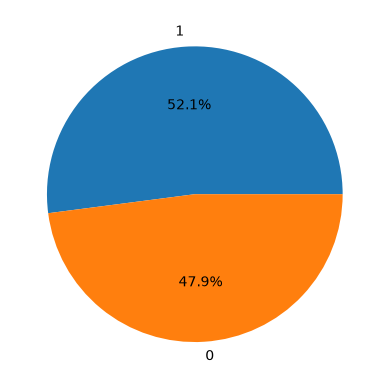

In [6]:
df.is_organic.value_counts().plot(kind="pie", autopct="%1.1f%%")

In [7]:
df.is_organic.value_counts()

is_organic
1    24876996
0    22913453
Name: count, dtype: int64

<Axes: xlabel='event_type'>

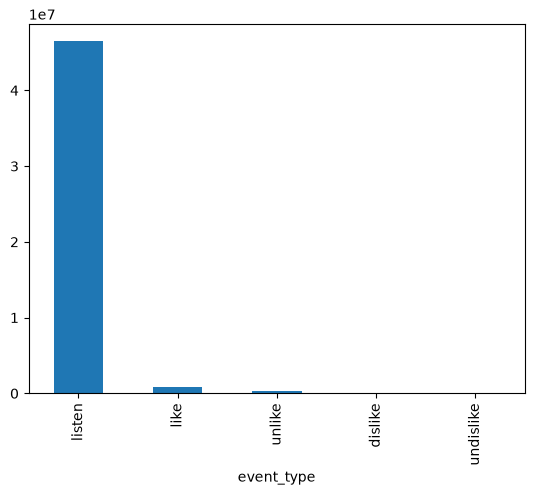

In [8]:
df.event_type.value_counts().plot(kind="bar")

In [9]:
df.event_type.value_counts()

event_type
listen       46467212
like           881456
unlike         312972
dislike        107776
undislike       21033
Name: count, dtype: int64

In [10]:
df[[ 'timestamp', 'played_ratio_pct', 'track_length_seconds']].describe()

,timestamp,played_ratio_pct,track_length_seconds
count,47790449.00,46467212.00,46467212.00
mean,14446548.21,64.76,207.41
std,7469606.18,44.09,89.21
min,0.00,0.00,5.00
25%,8185690.00,7.00,165.00
50%,15090975.00,100.00,200.00
75%,21061390.00,100.00,230.00
max,26000000.00,159.00,2495.00


Работаем только с неорганическими данными:

In [11]:
non_organic = df[df.is_organic == False].copy()
non_organic = non_organic.drop(columns=['is_organic'])
non_organic.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,100.00,170.00,listen
1,100,39420,1441281,100.00,105.00,listen
2,100,39625,286361,100.00,185.00,listen
3,100,40110,732449,100.00,240.00,listen
4,100,40360,3397170,46.00,130.00,listen


In [12]:
non_organic.event_type.value_counts()

event_type
listen       22463555
like           379255
dislike         51788
unlike          16531
undislike        2324
Name: count, dtype: int64

In [13]:
non_organic[[ 'timestamp', 'played_ratio_pct', 'track_length_seconds']].describe()

,timestamp,played_ratio_pct,track_length_seconds
count,22913453.00,22463555.00,22463555.00
mean,14302605.78,69.61,201.19
std,7537120.61,42.51,70.28
min,0.00,0.00,5.00
25%,7896020.00,16.00,165.00
50%,14884490.00,100.00,195.00
75%,21035230.00,100.00,230.00
max,26000000.00,159.00,2495.00


In [14]:
non_organic['is_listen'] = non_organic['event_type'] == 'listen'
non_organic['is_like'] = non_organic['event_type'] == 'like'
non_organic['is_dislike'] = non_organic['event_type'] == 'dislike'

non_organic['is_full_play'] = (non_organic['event_type'] == 'listen') & (non_organic['played_ratio_pct'] >= 90)
non_organic['is_skip'] = (non_organic['event_type'] == 'listen') & (non_organic['played_ratio_pct'] < 50)

non_organic  = non_organic.sort_values(["uid", "timestamp", "event_type", "item_id"], kind="mergesort")
non_organic.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type,is_listen,is_like,is_dislike,is_full_play,is_skip
1,100,39420,1441281,100.00,105.00,listen,True,False,False,True,False
0,100,39420,8326270,100.00,170.00,listen,True,False,False,True,False
2,100,39625,286361,100.00,185.00,listen,True,False,False,True,False
3,100,40110,732449,100.00,240.00,listen,True,False,False,True,False
4,100,40360,3397170,46.00,130.00,listen,True,False,False,False,True


In [15]:
listens = non_organic.loc[non_organic["is_listen"]].copy().reset_index(drop=True)
listens["listen_row_id"] = np.arange(len(listens), dtype=np.int64)

likes = non_organic.loc[non_organic["is_like"]].copy().reset_index(drop=True)
likes["like_idx"] = np.arange(len(likes), dtype=np.int64)

dislikes = non_organic.loc[non_organic["is_dislike"]].copy().reset_index(drop=True)
dislikes["dislike_idx"] = np.arange(len(dislikes), dtype=np.int64)

In [16]:
listens_new = listens[["uid", "item_id", "timestamp", "listen_row_id"]].rename(
    columns={"timestamp": "listen_ts"}
).sort_values(["listen_ts", "uid", "item_id"], kind="mergesort")

likes_new = likes[["uid", "item_id", "timestamp", "like_idx"]].rename(
    columns={"timestamp": "like_ts"}
).sort_values(["like_ts", "uid", "item_id"], kind="mergesort")

dislikes_new = dislikes[["uid", "item_id", "timestamp", "dislike_idx"]].rename(
    columns={"timestamp": "dislike_ts"}
).sort_values(["dislike_ts", "uid", "item_id"], kind="mergesort")

listens_new.head()

,uid,item_id,listen_ts,listen_row_id
10651722,468300,7400764,0,10651722
7761463,347600,3415205,5,7761463
21259899,942900,6728180,10,21259899
223234,12700,8932363,15,223234
14214139,631600,1652612,20,14214139


In [17]:
likes_new.head()

,uid,item_id,like_ts,like_idx
68803,190800,2214045,80,68803
233323,631600,1652612,1190,233323
129295,347600,1777844,2615,129295
80513,219100,1402386,2690,80513
186181,496700,2581708,3725,186181


In [18]:
dislikes_new.head()

,uid,item_id,dislike_ts,dislike_idx
33651,607000,8876988,6700,33651
33652,607000,5950157,7605,33652
40833,763600,4384330,10370,40833
36058,647400,3079656,12505,36058
36059,647400,4335158,12505,36059


In [19]:
prev_l = pd.merge_asof(
    likes_new,
    listens_new,
    left_on="like_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="backward",
).rename(columns={"listen_ts": "prev_listen_ts", "listen_row_id": "prev_listen_id"})

next_l = pd.merge_asof(
    likes_new,
    listens_new,
    left_on="like_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="forward",
).rename(columns={"listen_ts": "next_listen_ts", "listen_row_id": "next_listen_id"})

both_l = prev_l.merge(
    next_l[["like_idx", "next_listen_ts", "next_listen_id"]],
    on="like_idx",
    how="left",
)

In [20]:
prev_d = pd.merge_asof(
    dislikes_new,
    listens_new,
    left_on="dislike_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="backward",
).rename(columns={"listen_ts": "prev_listen_ts", "listen_row_id": "prev_listen_id"})

next_d = pd.merge_asof(
    dislikes_new,
    listens_new,
    left_on="dislike_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="forward",
).rename(columns={"listen_ts": "next_listen_ts", "listen_row_id": "next_listen_id"})

both_d = prev_d.merge(
    next_d[["dislike_idx", "next_listen_ts", "next_listen_id"]],
    on="dislike_idx",
    how="left",
)

Будем привязывать действие либо к ближайшему предыдущему прослушиванию за последние 3 часа, либо к последующему прослушиванию в рамках короткого окна (2 * макс. длина трека в датасете) на случай, если прослушивание логируется не одновременно с действием.

In [21]:
window_prev = 3 * 60 * 60
window_next =  2495 * 2

In [22]:
both_l["d_prev"] = (both_l["like_ts"] - both_l["prev_listen_ts"]).abs()
both_l.loc[both_l["prev_listen_ts"].isna(), "d_prev"] = np.nan
    
both_l["d_next"] = (both_l["next_listen_ts"] - both_l["like_ts"]).abs()
both_l.loc[both_l["next_listen_ts"].isna(), "d_next"] = np.nan

cand_prev_ok_l = both_l["prev_listen_ts"].notna() & (both_l["d_prev"] <= window_prev)
cand_next_ok_l = both_l["next_listen_ts"].notna() & (both_l["d_next"] <= window_next)

pick_prev_l = cand_prev_ok_l & (~cand_next_ok_l | (both_l["d_prev"] <= both_l["d_next"]))
pick_next_l = cand_next_ok_l & (~cand_prev_ok_l | (both_l["d_next"] < both_l["d_prev"]))

both_l["_chosen_listen_id"] = pd.Series(pd.NA, index=both_l.index, dtype="Int64")
both_l.loc[pick_prev_l, "_chosen_listen_id"] = both_l.loc[pick_prev_l, "prev_listen_id"].astype("Int64")
both_l.loc[pick_next_l, "_chosen_listen_id"] = both_l.loc[pick_next_l, "next_listen_id"].astype("Int64")


In [23]:
both_d["d_prev"] = (both_d["dislike_ts"] - both_d["prev_listen_ts"]).abs()
both_d.loc[both_d["prev_listen_ts"].isna(), "d_prev"] = np.nan
    
both_d["d_next"] = (both_d["next_listen_ts"] - both_d["dislike_ts"]).abs()
both_d.loc[both_d["next_listen_ts"].isna(), "d_next"] = np.nan

cand_prev_ok_d = both_d["prev_listen_ts"].notna() & (both_d["d_prev"] <= window_prev)
cand_next_ok_d = both_d["next_listen_ts"].notna() & (both_d["d_next"] <= window_next)

pick_prev_d = cand_prev_ok_d & (~cand_next_ok_d | (both_d["d_prev"] <= both_d["d_next"]))
pick_next_d = cand_next_ok_d & (~cand_prev_ok_d | (both_d["d_next"] < both_d["d_prev"]))

both_d["_chosen_listen_id"] = pd.Series(pd.NA, index=both_d.index, dtype="Int64")
both_d.loc[pick_prev_d, "_chosen_listen_id"] = both_d.loc[pick_prev_d, "prev_listen_id"].astype("Int64")
both_d.loc[pick_next_d, "_chosen_listen_id"] = both_d.loc[pick_next_d, "next_listen_id"].astype("Int64")

In [24]:
liked_ids = (
    both_l.loc[both_l["_chosen_listen_id"].notna(), ["_chosen_listen_id"]]
    .rename(columns={"_chosen_listen_id": "listen_row_id"})
    .drop_duplicates()
)

disliked_ids = (
    both_d.loc[both_d["_chosen_listen_id"].notna(), ["_chosen_listen_id"]]
    .rename(columns={"_chosen_listen_id": "listen_row_id"})
    .drop_duplicates()
)

listens = listens.merge(
    liked_ids.assign(_has_like=True),
    on="listen_row_id",
    how="left",
)
listens["is_like"] = listens["_has_like"].fillna(False).astype(bool)

listens = listens.merge(
    disliked_ids.assign(_has_dislike=True),
    on="listen_row_id",
    how="left",
)
listens["is_dislike"] = listens["_has_dislike"].fillna(False).astype(bool)

listens = listens.drop(
    columns=["listen_row_id", "_has_like", "_has_dislike", "is_listen", "event_type"],
    errors="ignore",
)

In [25]:
listens.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip
0,100,39420,1441281,100.00,105.00,False,False,True,False
1,100,39420,8326270,100.00,170.00,False,False,True,False
2,100,39625,286361,100.00,185.00,False,False,True,False
3,100,40110,732449,100.00,240.00,False,False,True,False
4,100,40360,3397170,46.00,130.00,False,False,False,True


In [26]:
listens.is_like.value_counts()

is_like
False    22087983
True       375572
Name: count, dtype: int64

In [27]:
listens.is_dislike.value_counts()

is_dislike
False    22412319
True        51236
Name: count, dtype: int64

In [28]:
def _cum_timeline(events, group, prefix):
    sort_cols = list(dict.fromkeys([*group, "timestamp", "event_type", "item_id"]))

    ev = events.sort_values(sort_cols, kind="mergesort").copy()

    ev["played_sum"] = (
        ev["played_ratio_pct"]
        .fillna(0)
        .astype("int64")
        * ev["is_listen"].astype("int64")
    )

    g = ev.groupby(group, sort=False)

    ev[f"{prefix}_c_listen"] = g["is_listen"].cumsum()
    ev[f"{prefix}_c_like"] = g["is_like"].cumsum()
    ev[f"{prefix}_c_dislike"] = g["is_dislike"].cumsum()
    ev[f"{prefix}_c_full"] = g["is_full_play"].cumsum()
    ev[f"{prefix}_c_skip"] = g["is_skip"].cumsum()
    ev[f"{prefix}_c_pr_sum"] = g["played_sum"].cumsum()

    return ev[
        group
        + [
            "timestamp",
            f"{prefix}_c_listen",
            f"{prefix}_c_like",
            f"{prefix}_c_dislike",
            f"{prefix}_c_full",
            f"{prefix}_c_skip",
            f"{prefix}_c_pr_sum",
        ]
    ].rename(columns={"timestamp": "_tl_ts"})

In [29]:
def _asof_features(listens, timeline, by, prefix, lag_seconds):
    by = list(by)

    tcols = [
        f"{prefix}_c_listen",
        f"{prefix}_c_like",
        f"{prefix}_c_dislike",
        f"{prefix}_c_full",
        f"{prefix}_c_skip",
        f"{prefix}_c_pr_sum",
    ]

    left = listens.copy()
    left["_eval_ts"] = (
        left["timestamp"].astype("int64") - int(lag_seconds)
    ).clip(lower=0).astype("uint32")

    left = left.sort_values(["_eval_ts", *by], kind="mergesort").reset_index(drop=True)
    right = timeline.sort_values(["_tl_ts", *by], kind="mergesort").reset_index(drop=True)

    joined = pd.merge_asof(
        left,
        right,
        left_on="_eval_ts",
        right_on="_tl_ts",
        by=by,
        direction="backward",
    )

    for c in tcols:
        joined[c] = joined[c].fillna(0)

    return joined.drop(columns=["_eval_ts", "_tl_ts"])

In [30]:
def _ratio(sum_col, cnt_col, df):
    return df[sum_col].astype("float64") / df[cnt_col].astype("float64").clip(lower=1)

In [31]:
DENSE_COLUMNS = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_dislike_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",
    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_dislike_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",
    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_dislike_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",
    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)

In [32]:
def add_lagged_features(listens, events, lag_seconds):

    u = _cum_timeline(events, ["uid"], "u")
    i = _cum_timeline(events, ["item_id"], "i")
    ui = _cum_timeline(events, ["uid", "item_id"], "ui")

    l = _asof_features(listens, u, ["uid"], "u", lag_seconds).rename(
        columns={
            "u_c_listen": "user_lag_listen_cnt",
            "u_c_like": "user_lag_like_cnt",
            "u_c_dislike": "user_lag_dislike_cnt",
            "u_c_full": "user_lag_full_play_cnt",
            "u_c_skip": "user_lag_skip_cnt",
            "u_c_pr_sum": "_user_pr_sum",
        }
    )

    l = _asof_features(l, i, ["item_id"], "i", lag_seconds).rename(
        columns={
            "i_c_listen": "item_lag_listen_cnt",
            "i_c_like": "item_lag_like_cnt",
            "i_c_dislike": "item_lag_dislike_cnt",
            "i_c_full": "item_lag_full_play_cnt",
            "i_c_skip": "item_lag_skip_cnt",
            "i_c_pr_sum": "_item_pr_sum",
        }
    )

    l = _asof_features(l, ui, ["uid", "item_id"], "ui", lag_seconds).rename(
        columns={
            "ui_c_listen": "ui_lag_listen_cnt",
            "ui_c_like": "ui_lag_like_cnt",
            "ui_c_dislike": "ui_lag_dislike_cnt",
            "ui_c_full": "ui_lag_full_play_cnt",
            "ui_c_skip": "ui_lag_skip_cnt",
            "ui_c_pr_sum": "_ui_pr_sum",
        }
    )

    l["user_lag_avg_played_ratio"] = _ratio("_user_pr_sum", "user_lag_listen_cnt", l)
    l["item_lag_avg_played_ratio"] = _ratio("_item_pr_sum", "item_lag_listen_cnt", l)
    l["ui_lag_avg_played_ratio"] = _ratio("_ui_pr_sum", "ui_lag_listen_cnt", l)

    l = l.drop(columns=["_user_pr_sum", "_item_pr_sum", "_ui_pr_sum"])

    for c in DENSE_COLUMNS:
        l[c] = l[c].astype("float64")

    return l


In [33]:
listens = add_lagged_features(listens, non_organic, 15 * 60)
listens

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip,user_lag_listen_cnt,...,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_dislike_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio
0,12700,630,1303151,100.00,360.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,12700,265,2873958,100.00,220.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,12700,485,8480681,99.00,145.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,12700,15,8932363,100.00,245.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,133500,825,603612,100.00,100.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22463550,190700,25999995,5984903,0.00,180.00,False,False,False,True,12942.00,...,247.00,132.00,38.00,0.00,0.00,18.00,18.00,18.86,67.28,52.39
22463551,363700,25999995,8869299,12.00,95.00,False,False,False,True,88.00,...,882.00,315.00,0.00,0.00,0.00,0.00,0.00,83.69,76.13,0.00
22463552,960700,25999995,7430313,100.00,135.00,False,False,True,False,750.00,...,406.00,29.00,0.00,0.00,0.00,0.00,0.00,64.76,93.29,0.00
22463553,144700,26000000,6281650,6.00,205.00,False,False,False,True,5567.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,82.68,0.00,0.00


* uid — уникальный идентификатор пользователя
* timestamp — время взаимодействия пользователя с треком (временная метка, округленная до 5 секунд)
* item_id — уникальный идентификатор музыкального трека
* played_ratio_pct — процент прослушивания трека пользователем (от 0 до 100)
* track_length_seconds — продолжительность трека в секундах
* is_like — признак того, что данное прослушивание было связано с лайком пользователя
* is_dislike — признак того, что данное прослушивание было связано с дизлайком пользователя
* is_full_play — признак того, что трек был практически полностью прослушан пользователем
* is_skip — признак того, что трек был быстро пропущен пользователем
* user_lag_listen_cnt — количество прослушиваний, совершенных пользователем до текущего момента времени
* user_lag_like_cnt — количество лайков, поставленных пользователем до текущего момента времени
* user_lag_dislike_cnt — количество дизлайков, поставленных пользователем до текущего момента времени
* user_lag_full_play_cnt — количество полных прослушиваний пользователя до текущего момента времени
* user_lag_skip_cnt — количество пропусков треков пользователем до текущего момента времени
* item_lag_listen_cnt — количество прослушиваний данного трека всеми пользователями до текущего момента времени
* item_lag_like_cnt — количество лайков, полученных данным треком до текущего момента времени
* item_lag_dislike_cnt — количество дизлайков, полученных данным треком до текущего момента времени
* item_lag_full_play_cnt — количество полных прослушиваний данного трека до текущего момента времени
* item_lag_skip_cnt — количество случаев пропуска данного трека до текущего момента времени
* ui_lag_listen_cnt — количество предыдущих прослушиваний данного трека этим пользователем
* ui_lag_like_cnt — количество лайков, которые пользователь ранее поставил этому треку
* ui_lag_dislike_cnt — количество дизлайков, которые пользователь ранее поставил этому треку
* ui_lag_full_play_cnt — количество полных прослушиваний данного трека этим пользователем
* ui_lag_skip_cnt — количество случаев, когда пользователь ранее пропускал данный трек
* user_lag_avg_played_ratio — средний процент прослушивания треков пользователем до текущего момента времени
* item_lag_avg_played_ratio — средний процент прослушивания данного трека всеми пользователями до текущего момента времени
* ui_lag_avg_played_ratio — средний процент прослушивания данного трека конкретным пользователем до текущего момента времени

In [34]:
listens.dtypes

uid                           uint32
timestamp                     uint32
item_id                       uint32
played_ratio_pct             float64
track_length_seconds         float64
is_like                         bool
is_dislike                      bool
is_full_play                    bool
is_skip                         bool
user_lag_listen_cnt          float64
user_lag_like_cnt            float64
user_lag_dislike_cnt         float64
user_lag_full_play_cnt       float64
user_lag_skip_cnt            float64
item_lag_listen_cnt          float64
item_lag_like_cnt            float64
item_lag_dislike_cnt         float64
item_lag_full_play_cnt       float64
item_lag_skip_cnt            float64
ui_lag_listen_cnt            float64
ui_lag_like_cnt              float64
ui_lag_dislike_cnt           float64
ui_lag_full_play_cnt         float64
ui_lag_skip_cnt              float64
user_lag_avg_played_ratio    float64
item_lag_avg_played_ratio    float64
ui_lag_avg_played_ratio      float64
d

## Кодирование

In [35]:
from datasets import DatasetDict, load_dataset
import gc
import math

In [36]:
def extract_preference_pairs(df):
    out = df.copy()
    out["row_id"] = np.arange(len(out))

    out = out.sort_values(
        ["uid", "timestamp", "row_id"]
    ).reset_index(drop=True)

    group = out.groupby("uid", sort=False)

    prev_like = group["is_like"].shift(1)
    next_like = group["is_like"].shift(-1)

    prev_dislike = group["is_dislike"].shift(1)
    next_dislike = group["is_dislike"].shift(-1)

    prev_full = group["is_full_play"].shift(1)
    next_full = group["is_full_play"].shift(-1)

    diff_prev = (
        prev_like.notna()
        & (
            out["is_like"].ne(prev_like)
            | out["is_dislike"].ne(prev_dislike)
            | out["is_full_play"].ne(prev_full)
        )
    )

    diff_next = (
        next_like.notna()
        & (
            out["is_like"].ne(next_like)
            | out["is_dislike"].ne(next_dislike)
            | out["is_full_play"].ne(next_full)
        )
    )

    return (
        out[diff_prev | diff_next]
        .drop(columns=["row_id"])
        .reset_index(drop=True)
    )

In [37]:
listens = extract_preference_pairs(listens)

In [38]:
listens

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip,user_lag_listen_cnt,...,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_dislike_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio
0,100,40110,732449,100.00,240.00,False,False,True,False,0.00,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,50.50,0.00
1,100,40360,3397170,46.00,130.00,False,False,False,True,2.00,...,3.00,1.00,0.00,0.00,0.00,0.00,0.00,100.00,83.25,0.00
2,100,40380,7849270,100.00,205.00,False,False,True,False,2.00,...,4.00,3.00,0.00,0.00,0.00,0.00,0.00,100.00,57.43,0.00
3,100,41130,6474571,100.00,245.00,False,False,True,False,4.00,...,0.00,2.00,0.00,0.00,0.00,0.00,0.00,100.00,7.00,0.00
4,100,41545,7847600,27.00,250.00,False,False,False,True,7.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,92.29,100.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6939275,1000000,25277150,7479030,99.00,155.00,False,False,True,False,361.00,...,711.00,60.00,0.00,0.00,0.00,0.00,0.00,92.73,92.41,0.00
6939276,1000000,25277170,9295648,15.00,120.00,False,False,False,True,361.00,...,3804.00,745.00,0.00,0.00,0.00,0.00,0.00,92.73,84.59,0.00
6939277,1000000,25960045,1914019,100.00,185.00,False,False,True,False,365.00,...,1501.00,903.00,0.00,0.00,0.00,0.00,0.00,92.31,65.35,0.00
6939278,1000000,25962060,3732104,100.00,255.00,False,False,True,False,371.00,...,1605.00,1136.00,0.00,0.00,0.00,0.00,0.00,92.43,61.90,0.00


In [39]:
def load_yambda_table(filename):
    data = load_dataset(
        "yandex/yambda",
        data_dir="",
        data_files=f"{filename}.parquet",
    )

    assert isinstance(data, DatasetDict)
    return data["train"].to_pandas()


albums = load_yambda_table("album_item_mapping")
artists = load_yambda_table("artist_item_mapping")

In [40]:
def build_list_mapping(
    df,
    key_col,
    value_col):
    return (
        df
        .drop_duplicates([key_col, value_col])
        .sort_values([key_col, value_col])
        .groupby(key_col)[value_col]
        .agg(list)
        .to_dict()
    )


def join_item_artist_album(
    listens,
    artists,
    albums,
):
    out = listens.copy()

    artist_map = build_list_mapping(artists, "item_id", "artist_id")
    album_map = build_list_mapping(albums, "item_id", "album_id")

    out["artist_ids"] = out["item_id"].map(artist_map)
    out["album_ids"] = out["item_id"].map(album_map)

    out["artist_ids"] = out["artist_ids"].apply(lambda x: x if isinstance(x, list) else [])
    out["album_ids"] = out["album_ids"].apply(lambda x: x if isinstance(x, list) else [])


    return out

listens = join_item_artist_album(listens, artists, albums)

del artists, albums
gc.collect()

0

In [41]:
def temporal_train_test_split(
    df: pd.DataFrame,
    test_last_seconds: float,
    time_column: str = "timestamp",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    max_time = df[time_column].max()
    split_time = max_time - test_last_seconds

    train = df[df[time_column] < split_time].copy()
    test = df[df[time_column] >= split_time].copy()

    return train.reset_index(drop=True), test.reset_index(drop=True)

train_listens, test_listens = temporal_train_test_split(listens, test_last_seconds=30 * 24 * 60 * 60)

del listens
gc.collect()

0

In [42]:
DENSE_COLUMNS = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_dislike_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",

    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_dislike_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",

    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_dislike_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",

    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)

SPARSE_COLUMNS = (
    "uid_hash",
    "item_id_hash",
)

MULTIVALENT_COLUMNS = (
    "artist_hash_ids",
    "album_hash_ids",
)

LABEL_COLUMNS = (
    "is_like",
    "is_dislike",
    "is_full_play",
    "is_skip",
)

In [43]:
def hash_id_list(xs, cardinality):
    if not isinstance(xs, list):
        return []

    return [x % cardinality for x in xs]


def add_hashed_features(df, uid_cardinality, item_cardinality, meta_cardinality):
    df = df.copy()

    df["uid_hash"] = df["uid"] % uid_cardinality
    df["item_id_hash"] = df["item_id"] % item_cardinality

    df["artist_hash_ids"] = df["artist_ids"].apply(
        lambda xs: hash_id_list(xs, meta_cardinality)
    )

    df["album_hash_ids"] = df["album_ids"].apply(
        lambda xs: hash_id_list(xs, meta_cardinality)
    )

    return df

In [44]:
class RankerDataset:
    def __init__(
        self,
        df: pd.DataFrame,
        label_columns: list[str],
        dense_columns: list[str],
        sparse_columns: list[str],
        multivalent_columns: list[str],
        batch_size: int,
    ):
        if batch_size < 1:
            raise ValueError("batch_size must be >= 1")

        self.df = df.reset_index(drop=True)
        self.label_columns = list(label_columns)
        self.dense_columns = list(dense_columns)
        self.sparse_columns = list(sparse_columns)
        self.multivalent_columns = list(multivalent_columns)
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min(start + self.batch_size, len(self.df))

        batch_df = self.df.iloc[start:end]

        batch = {
            "labels": self._make_labels(batch_df),
            "dense_features": self._make_dense_features(batch_df),
            "sparse_features": self._make_sparse_features(batch_df),
            "multivalent_features": self._make_multivalent_features(batch_df),
            "meta": self._make_meta(batch_df),
        }

        return batch

    def _make_labels(self, batch_df: pd.DataFrame):
        return {
            col: torch.tensor(
                batch_df[col].to_numpy(dtype=np.float32),
                dtype=torch.float32,
            )
            for col in self.label_columns
        }

    def _make_dense_features(self, batch_df: pd.DataFrame):
        return torch.tensor(
            batch_df[self.dense_columns].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

    def _make_sparse_features(self, batch_df: pd.DataFrame):
        return {
            col: torch.tensor(
                batch_df[col].to_numpy(),
                dtype=torch.long,
            )
            for col in self.sparse_columns
        }

    def _make_multivalent_features(self, batch_df: pd.DataFrame):
        result = {}

        for col in self.multivalent_columns:
            lists = batch_df[col].tolist()

            values = []
            offsets = []
            lengths = []

            current_offset = 0

            for x in lists:
                offsets.append(current_offset)

                if isinstance(x, list):
                    values.extend(x)
                    current_offset += len(x)
                    lengths.append(len(x))
                else:
                    lengths.append(0)

            result[col] = {
                "values": torch.tensor(values, dtype=torch.long),
                "offsets": torch.tensor(offsets, dtype=torch.long),
                "lengths": torch.tensor(lengths, dtype=torch.long),
            }

        return result

    def _make_meta(self, batch_df: pd.DataFrame):
        return {
            "timestamp": torch.tensor(
                batch_df["timestamp"].to_numpy(),
                dtype=torch.long,
            ),
            "uid": torch.tensor(
                batch_df["uid"].to_numpy(),
                dtype=torch.long,
            ),
            "item_id": torch.tensor(
                batch_df["item_id"].to_numpy(),
                dtype=torch.long,
            ),
        }


In [45]:
import torch.nn as nn
import torch

class PiecewiseLinearEncoder(nn.Module):
    @staticmethod
    def compute_bins(X, n_bins):
        quantiles = torch.linspace(
            0.0,
            1.0,
            n_bins + 1,
            device=X.device,
            dtype=X.dtype,
        )

        bins = []

        for feature_idx in range(X.shape[1]):
            col = X[:, feature_idx]
            feature_bins = torch.quantile(col, quantiles)
            feature_bins = torch.unique(feature_bins, sorted=True)

            if len(feature_bins) < 2:
                value = col.min()
                feature_bins = torch.tensor(
                    [value, value + 1.0],
                    device=X.device,
                    dtype=X.dtype,
                )

            bins.append(feature_bins)

        return bins

    @classmethod
    def from_dataset(cls, dense_train_df, n_bins=32, train_df_slice=1_000_000):
        X = torch.tensor(
            dense_train_df.iloc[:train_df_slice].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        bins = cls.compute_bins(X, n_bins)

        n_bins_per_feature = [len(b) - 1 for b in bins]
        max_n_bins = max(n_bins_per_feature)
        n_features = len(bins)

        weight = torch.zeros(n_features, max_n_bins)
        bias = torch.zeros(n_features, max_n_bins)

        for feature_idx, feature_bins in enumerate(bins):
            left = feature_bins[:-1]
            right = feature_bins[1:]

            w = 1.0 / (right - left)
            b = -left / (right - left)

            cur_n_bins = len(feature_bins) - 1

            weight[feature_idx, :cur_n_bins] = w
            bias[feature_idx, :cur_n_bins] = b

        if len(set(n_bins_per_feature)) == 1:
            mask = None
        else:
            mask = torch.zeros(n_features, max_n_bins, dtype=torch.bool)

            for feature_idx, cur_n_bins in enumerate(n_bins_per_feature):
                mask[feature_idx, :cur_n_bins] = True

            mask = mask.flatten()

        return cls(weight, bias, mask, n_bins_per_feature)

    def __init__(self, weight, bias, mask, n_bins):
        super().__init__()

        self._n_bins = list(n_bins)

        self.register_buffer("weight", weight)
        self.register_buffer("bias", bias)

        if mask is None:
            self.mask = None
        else:
            self.register_buffer("mask", mask)

    @property
    def n_bins(self):
        return self._n_bins

    def forward(self, x):
        x = x.to(self.weight.dtype)

        out = self.bias.unsqueeze(0) + self.weight.unsqueeze(0) * x.unsqueeze(-1)

        first = out[..., :1].clamp_max(1.0)
        middle = out[..., 1:-1].clamp(0.0, 1.0)
        last = out[..., -1:].clamp_min(0.0)

        out = torch.cat([first, middle, last], dim=-1)
        out = out.flatten(start_dim=1)

        if self.mask is not None:
            out = out[:, self.mask]

        return out

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"

EMBEDDING_SIZE = 32
N_BINS = 32
TRAIN_DF_SLICE = 1000000
BATCH_SIZE = 4096

UID_CARDINALITY = 200000
ITEM_CARDINALITY = 200000
META_CARDINALITY = 100000

In [47]:
train_listens_dense = train_listens[list(DENSE_COLUMNS)].copy()

train_listens = add_hashed_features(
    train_listens,
    uid_cardinality=UID_CARDINALITY,
    item_cardinality=ITEM_CARDINALITY,
    meta_cardinality=META_CARDINALITY,
)

test_listens = add_hashed_features(
    test_listens,
    uid_cardinality=UID_CARDINALITY,
    item_cardinality=ITEM_CARDINALITY,
    meta_cardinality=META_CARDINALITY,
)

In [48]:
train_dataset = RankerDataset(
    df=train_listens,
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=BATCH_SIZE,
)

test_dataset = RankerDataset(
    df=test_listens,
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=BATCH_SIZE,
)

In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=None,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=None,
    shuffle=False,
    num_workers=0,
)

In [75]:
class FeatureExtractor(nn.Module):
    def __init__(
        self,
        embedding_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        uid_cardinality,
        item_cardinality,
        meta_cardinality,
    ):
        super().__init__()

        self.uid_emb = nn.Embedding(uid_cardinality, embedding_size)
        self.item_emb = nn.Embedding(item_cardinality, embedding_size)

        self.artist_emb = nn.EmbeddingBag(
            meta_cardinality,
            embedding_size,
            mode="mean",
        )

        self.album_emb = nn.EmbeddingBag(
            meta_cardinality,
            embedding_size,
            mode="mean",
        )

        self.dense_encoder = PiecewiseLinearEncoder.from_dataset(
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice,
        )

        self.output_dim = sum(self.dense_encoder.n_bins) + 4 * embedding_size

    @staticmethod
    def bag_forward(embedding_bag, values, offsets):
        batch_size = offsets.shape[0]

        if values.numel() == 0:
            return torch.zeros(
                batch_size,
                embedding_bag.embedding_dim,
                device=offsets.device,
                dtype=embedding_bag.weight.dtype,
            )

        return embedding_bag(values, offsets)

    def forward(self, batch):
        dense_features = self.dense_encoder(batch["dense_features"])

        uid_features = self.uid_emb(
            batch["sparse_features"]["uid_hash"]
        )

        item_features = self.item_emb(
            batch["sparse_features"]["item_id_hash"]
        )

        artist_features = self.bag_forward(
            self.artist_emb,
            batch["multivalent_features"]["artist_hash_ids"]["values"],
            batch["multivalent_features"]["artist_hash_ids"]["offsets"],
        )

        album_features = self.bag_forward(
            self.album_emb,
            batch["multivalent_features"]["album_hash_ids"]["values"],
            batch["multivalent_features"]["album_hash_ids"]["offsets"],
        )

        return torch.cat(
            [
                dense_features,
                uid_features,
                item_features,
                artist_features,
                album_features,
            ],
            dim=1,
        )

# MLP

In [61]:
class MLPModel(nn.Module):
    def __init__(
        self,
        embedding_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        uid_cardinality,
        item_cardinality,
        meta_cardinality,
    ):
        super().__init__()

        self.features = FeatureExtractor(
            embedding_size=embedding_size,
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice,
            uid_cardinality=uid_cardinality,
            item_cardinality=item_cardinality,
            meta_cardinality=meta_cardinality,
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.features.output_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.output_layer = nn.Linear(32, 1)

    def forward(self, batch):
        x = self.features(batch)
        x = self.mlp(x)
        return self.output_layer(x)

In [62]:
def to_device(x, device):
    if isinstance(x, torch.Tensor):
        return x.to(device)

    if isinstance(x, dict):
        return {
            key: to_device(value, device)
            for key, value in x.items()
        }

    return x

In [63]:
def pairwise_accuracy(df, score_col, label_col):
    df = df.sort_values(["uid", "timestamp", "item_id"]).reset_index(drop=True)

    same_user = df["uid"].values[1:] == df["uid"].values[:-1]

    y_prev = df[label_col].values[:-1]
    y_next = df[label_col].values[1:]

    s_prev = df[score_col].values[:-1]
    s_next = df[score_col].values[1:]

    diff_mask = same_user & (y_prev != y_next)

    if diff_mask.sum() == 0:
        return 0.0

    y_diff = y_next[diff_mask] - y_prev[diff_mask]
    s_diff = s_next[diff_mask] - s_prev[diff_mask]

    return float((y_diff * s_diff > 0).mean())

In [64]:
@torch.no_grad()
def evaluate_model(model, test_loader):
    model.eval()

    device = next(model.parameters()).device
    rows = []

    for batch in test_loader:
        batch = to_device(batch, device)

        logits = model(batch).squeeze(1)

        batch_df = pd.DataFrame(
            {
                "uid": batch["meta"]["uid"].detach().cpu().numpy(),
                "item_id": batch["meta"]["item_id"].detach().cpu().numpy(),
                "timestamp": batch["meta"]["timestamp"].detach().cpu().numpy(),
                "is_like": batch["labels"]["is_like"].detach().cpu().numpy(),
                "is_full_play": batch["labels"]["is_full_play"].detach().cpu().numpy(),
                "not_skip": 1.0 - batch["labels"]["is_skip"].detach().cpu().numpy(),
                "score": logits.detach().cpu().numpy(),
            }
        )

        rows.append(batch_df)

    pred_df = pd.concat(rows, ignore_index=True)

    return {
        "pair_accuracy_full_play": pairwise_accuracy(
            pred_df,
            score_col="score",
            label_col="is_full_play",
        ),
        "pair_accuracy_like": pairwise_accuracy(
            pred_df,
            score_col="score",
            label_col="is_like",
        )
    }

In [81]:
import wandb
from tqdm import tqdm

def train_model(model, run_name, epochs=5, lr=1e-3, weight_decay=0.0, config=None):
    if config is None:
        config = {}

    wandb.init(
        project="yambda-recsys",
        name=run_name,
        config={
            "model": run_name,
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay,
            **config,
        },
    )

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    ...
    wandb.init(
        project="recsys",
        name=run_name,
        config={
            "model": run_name,
            "epochs": epochs,
            "lr": lr,
            "embedding_size": EMBEDDING_SIZE,
            "n_bins": N_BINS,
            "batch_size": BATCH_SIZE,
        },
    )

    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    last_metrics = None
    global_step = 0

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []

        pbar = tqdm(train_loader, desc=f"{run_name} | epoch {epoch}/{epochs}")

        for step, batch in enumerate(pbar, start=1):
            batch = to_device(batch, device)

            target = batch["labels"]["is_full_play"].unsqueeze(1).float()

            logits = model(batch)

            loss = criterion(logits, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            global_step += 1

            if step % 100 == 0:
                step_loss = float(np.mean(losses[-100:]))
                pbar.set_postfix(loss=step_loss)

                wandb.log(
                    {
                        "train/loss_step": step_loss,
                        "epoch": epoch,
                        "global_step": global_step,
                    }
                )

        train_loss = float(np.mean(losses))
        last_metrics = evaluate_model(model, test_loader)

        log_dict = {
            "train/loss_epoch": train_loss,
            "epoch": epoch,
        }

        for key, value in last_metrics.items():
            log_dict[f"test/{key}"] = value

        wandb.log(log_dict)

        print(f"\n{run_name} | epoch {epoch}")
        print(f"train_loss: {train_loss:.3f}")

        for key, value in last_metrics.items():
            print(f"{key}: {value:.3f}")

    wandb.finish()

    return model, last_metrics

In [67]:
results = {}

model_mlp = MLPModel(
    embedding_size=256,
    dense_train_df=train_listens_dense,
    n_bins=N_BINS,
    train_df_slice=TRAIN_DF_SLICE,
    uid_cardinality=UID_CARDINALITY,
    item_cardinality=ITEM_CARDINALITY,
    meta_cardinality=META_CARDINALITY,
)

model_mlp, metrics_mlp = train_model(
    model=model_mlp,
    run_name="mlp (e=256)",
    epochs=3,
    lr=1e-3,
)

results["mlp"] = metrics_mlp

mlp (e=256) | epoch 1/3: 100%|██████████| 1466/1466 [02:52<00:00,  8.50it/s, loss=0.669]



mlp (e=256) | epoch 1
train_loss: 0.674
pair_accuracy_full_play: 0.575
pair_accuracy_like: 0.478


mlp (e=256) | epoch 2/3: 100%|██████████| 1466/1466 [02:59<00:00,  8.16it/s, loss=0.66] 



mlp (e=256) | epoch 2
train_loss: 0.667
pair_accuracy_full_play: 0.577
pair_accuracy_like: 0.481


mlp (e=256) | epoch 3/3: 100%|██████████| 1466/1466 [02:55<00:00,  8.37it/s, loss=0.658]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.



mlp (e=256) | epoch 3
train_loss: 0.661
pair_accuracy_full_play: 0.575
pair_accuracy_like: 0.480


epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅█████████████
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test/pair_accuracy_full_play,▁█▁
test/pair_accuracy_like,▁█▆
train/loss_epoch,█▄▁
train/loss_step,█▆▆▆▆▅▅▅▄▅▄▅▅▄▃▄▄▃▃▄▃▄▄▃▄▄▂▂▃▂▂▁▂▂▂▂▃▂▂▁
epoch,3
global_step,4332
test/pair_accuracy_full_play,0.57476
test/pair_accuracy_like,0.47976
train/loss_epoch,0.661


# DCN-V2

In [76]:
class MixtureLowRankCrossLayer(nn.Module):
    def __init__(
        self,
        input_dim,
        num_experts=2,
        rank=16,
    ):
        super().__init__()

        self.U = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.V = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.bias = nn.Parameter(torch.zeros(input_dim))

        self.gate = nn.Linear(input_dim, num_experts)

        nn.init.xavier_uniform_(self.U)
        nn.init.xavier_uniform_(self.V)

    def forward(self, x0, xl):
        v = torch.einsum("bd,edr->ber", xl, self.V)
        u = torch.einsum("ber,edr->bed", v, self.U)

        expert_outputs = x0.unsqueeze(1) * (
            u + self.bias.view(1, 1, -1)
        )

        gate_weights = torch.softmax(
            self.gate(xl),
            dim=1,
        ).unsqueeze(-1)

        cross = (expert_outputs * gate_weights).sum(dim=1)

        return cross + xl


class MixtureLowRankCrossNetwork(nn.Module):
    def __init__(
        self,
        input_dim,
        num_layers=1,
        num_experts=2,
        rank=16,
    ):
        super().__init__()

        self.layers = nn.ModuleList(
            [
                MixtureLowRankCrossLayer(
                    input_dim=input_dim,
                    num_experts=num_experts,
                    rank=rank,
                )
                for _ in range(num_layers)
            ]
        )

    def forward(self, x):
        x0 = x
        xl = x

        for layer in self.layers:
            xl = layer(x0, xl)

        return xl

In [77]:
class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_dim,
        out_dim,
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        layers = [
            nn.Linear(in_dim, out_dim),
        ]

        if use_batchnorm:
            layers.append(nn.BatchNorm1d(out_dim))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(out_dim, out_dim))

        self.net = nn.Sequential(*layers)

        if in_dim == out_dim:
            self.proj = nn.Identity()
        else:
            self.proj = nn.Linear(in_dim, out_dim)

        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(
            self.net(x) + self.proj(x)
        )


class ResDeepNetwork(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_units=(256, 128),
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        dims = [input_dim] + list(hidden_units)

        self.net = nn.Sequential(
            *[
                ResidualBlock(
                    in_dim=dims[i],
                    out_dim=dims[i + 1],
                    dropout=dropout,
                    use_batchnorm=use_batchnorm,
                )
                for i in range(len(dims) - 1)
            ]
        )

        self.output_dim = dims[-1]

    def forward(self, x):
        return self.net(x)
    


In [78]:
class DenseDeepNetwork(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_units=(256, 128),
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        self.layers = nn.ModuleList()
        self.batchnorms = nn.ModuleList()

        current_dim = input_dim

        for hidden_dim in hidden_units:
            self.layers.append(nn.Linear(current_dim, hidden_dim))

            if use_batchnorm:
                self.batchnorms.append(nn.BatchNorm1d(hidden_dim))
            else:
                self.batchnorms.append(nn.Identity())

            current_dim += hidden_dim

        self.activation = nn.ReLU()

        if dropout > 0:
            self.dropout = nn.Dropout(dropout)
        else:
            self.dropout = nn.Identity()

        self.output_dim = hidden_units[-1]

    def forward(self, x):
        features = [x]

        for layer, batchnorm in zip(self.layers, self.batchnorms):
            layer_input = torch.cat(features, dim=1)
            layer_output = layer(layer_input)
            layer_output = batchnorm(layer_output)
            layer_output = self.activation(layer_output)
            layer_output = self.dropout(layer_output)

            features.append(layer_output)

        return features[-1]

In [79]:
class DCNV2Model(nn.Module):
    def __init__(
        self,
        embedding_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        uid_cardinality,
        item_cardinality,
        meta_cardinality,
        deep_type="mlp",
        deep_units=(256, 128),
        dropout=0.0,
        use_batchnorm=False,
        cross_layers=1,
        num_experts=2,
        low_rank=16,
        output_size=1,
    ):
        super().__init__()

        self.features = FeatureExtractor(
            embedding_size=embedding_size,
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice,
            uid_cardinality=uid_cardinality,
            item_cardinality=item_cardinality,
            meta_cardinality=meta_cardinality,
        )

        input_dim = self.features.output_dim

        self.cross_network = MixtureLowRankCrossNetwork(
            input_dim=input_dim,
            num_layers=cross_layers,
            num_experts=num_experts,
            rank=low_rank,
        )

        if deep_type == "mlp":
            layers = []
            prev_dim = input_dim

            for hidden_dim in deep_units:
                layers.append(nn.Linear(prev_dim, hidden_dim))

                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(hidden_dim))

                layers.append(nn.ReLU())

                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

                prev_dim = hidden_dim

            self.deep_network = nn.Sequential(*layers)
            deep_output_dim = prev_dim

        elif deep_type == "resdeep":
            self.deep_network = ResDeepNetwork(
                input_dim=input_dim,
                hidden_units=deep_units,
                dropout=dropout,
                use_batchnorm=use_batchnorm,
            )

            deep_output_dim = self.deep_network.output_dim

        elif deep_type == "densedeep":
            self.deep_network = DenseDeepNetwork(
                input_dim=input_dim,
                hidden_units=deep_units,
                dropout=dropout,
                use_batchnorm=use_batchnorm,
            )

            deep_output_dim = self.deep_network.output_dim

        else:
            raise ValueError(f"Unknown deep_type: {deep_type}")

        self.output_layer = nn.Linear(
            input_dim + deep_output_dim,
            output_size,
        )

    def forward(self, batch):
        x = self.features(batch)

        cross_output = self.cross_network(x)
        deep_output = self.deep_network(x)

        out = torch.cat(
            [
                cross_output,
                deep_output,
            ],
            dim=1,
        )

        return self.output_layer(out)

# DCN-V2 + MLP

In [83]:
model_dcnv2_mlp_cross1 = DCNV2Model(
    embedding_size=16,
    dense_train_df=train_listens_dense,
    n_bins=32,
    train_df_slice=TRAIN_DF_SLICE,
    uid_cardinality=UID_CARDINALITY,
    item_cardinality=ITEM_CARDINALITY,
    meta_cardinality=META_CARDINALITY,
    deep_type="mlp",
    deep_units=(256, 128),
    dropout=0.1,
    use_batchnorm=False,
    cross_layers=3,
    num_experts=2,
    low_rank=16,
)

model_dcnv2_mlp_cross1, metrics_dcnv2_mlp_cross1 = train_model(
    model=model_dcnv2_mlp_cross1,
    run_name="dcnv2_mlp_cross1",
    epochs=5,
    lr=3e-4,
    weight_decay=1e-5,
    config={
        "embedding_size": 16,
        "n_bins": 32,
        "deep_type": "mlp",
        "deep_units": [256, 128],
        "dropout": 0.1,
        "use_batchnorm": False,
        "cross_layers": 3,
        "num_experts": 2,
        "low_rank": 16,
    },
)

results["dcnv2_mlp_cross1"] = metrics_dcnv2_mlp_cross1

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dcnv2_mlp_cross1 | epoch 1/5: 100%|██████████| 1466/1466 [01:27<00:00, 16.73it/s, loss=0.67] 



dcnv2_mlp_cross1 | epoch 1
train_loss: 0.671
pair_accuracy_full_play: 0.575
pair_accuracy_like: 0.481


dcnv2_mlp_cross1 | epoch 2/5: 100%|██████████| 1466/1466 [01:27<00:00, 16.71it/s, loss=0.669]



dcnv2_mlp_cross1 | epoch 2
train_loss: 0.668
pair_accuracy_full_play: 0.577
pair_accuracy_like: 0.481


...

dcnv2_mlp_cross1 | epoch 4/5: 100%|██████████| 1466/1466 [01:29<00:00, 16.40it/s, loss=0.669]



dcnv2_mlp_cross1 | epoch 4
train_loss: 0.666
pair_accuracy_full_play: 0.578
pair_accuracy_like: 0.480


dcnv2_mlp_cross1 | epoch 5/5: 100%|██████████| 1466/1466 [01:29<00:00, 16.32it/s, loss=0.667]



dcnv2_mlp_cross1 | epoch 5
train_loss: 0.665
pair_accuracy_full_play: 0.575
pair_accuracy_like: 0.482


epoch,▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆████████
global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test/pair_accuracy_full_play,▁▅▁█▁
test/pair_accuracy_like,▃▄█▁▆
train/loss_epoch,█▄▃▂▁
train/loss_step,▇█▇▆▅▄▅▄▃▄▄▄▅▆▃▆▅▅▄▆▄▃▂▅▄▂▄▅▂▄▄▃▅▄▄▅▄▄▅▁
epoch,5
global_step,7264
test/pair_accuracy_full_play,0.57523
test/pair_accuracy_like,0.48157
train/loss_epoch,0.66529


In [84]:
EPOCHS = 5
LR = 3e-4
WEIGHT_DECAY = 1e-5

grid_results = {}

cross_layers_values = [1, 2, 3]
low_rank_values = [8, 16, 32]

for cross_layers in cross_layers_values:
    for low_rank in low_rank_values:
        run_name = f"dcnv2_mlp_cross{cross_layers}_rank{low_rank}"

        print("=" * 80)
        print(f"Start experiment: {run_name}")
        print("=" * 80)

        model = DCNV2Model(
            embedding_size=16,
            dense_train_df=train_listens_dense,
            n_bins=32,
            train_df_slice=TRAIN_DF_SLICE,
            uid_cardinality=UID_CARDINALITY,
            item_cardinality=ITEM_CARDINALITY,
            meta_cardinality=META_CARDINALITY,
            deep_type="mlp",
            deep_units=(256, 128),
            dropout=0.1,
            use_batchnorm=False,
            cross_layers=cross_layers,
            num_experts=2,
            low_rank=low_rank,
        )

        model, metrics = train_model(
            model=model,
            run_name=run_name,
            epochs=EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            config={
                "architecture": "DCNV2 + MLP",
                "target": "is_full_play",
                "embedding_size": 16,
                "n_bins": 32,
                "deep_type": "mlp",
                "deep_units": [256, 128],
                "dropout": 0.1,
                "use_batchnorm": False,
                "cross_layers": cross_layers,
                "num_experts": 2,
                "low_rank": low_rank,
            },
        )

        grid_results[run_name] = {
            "cross_layers": cross_layers,
            "low_rank": low_rank,
            **metrics,
        }

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

Start experiment: dcnv2_mlp_cross1_rank8


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dcnv2_mlp_cross1_rank8 | epoch 1/5: 100%|██████████| 1466/1466 [00:53<00:00, 27.21it/s, loss=0.672]



dcnv2_mlp_cross1_rank8 | epoch 1
train_loss: 0.672
pair_accuracy_full_play: 0.574
pair_accuracy_like: 0.479


dcnv2_mlp_cross1_rank8 | epoch 2/5: 100%|██████████| 1466/1466 [00:53<00:00, 27.17it/s, loss=0.665]


...

dcnv2_mlp_cross3_rank32 | epoch 4/5: 100%|██████████| 1466/1466 [01:35<00:00, 15.28it/s, loss=0.672]



dcnv2_mlp_cross3_rank32 | epoch 4
train_loss: 0.666
pair_accuracy_full_play: 0.577
pair_accuracy_like: 0.479


dcnv2_mlp_cross3_rank32 | epoch 5/5: 100%|██████████| 1466/1466 [01:34<00:00, 15.56it/s, loss=0.667]



dcnv2_mlp_cross3_rank32 | epoch 5
train_loss: 0.665
pair_accuracy_full_play: 0.576
pair_accuracy_like: 0.480


epoch,▁▁▁▁▁▁▁▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆████████
global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
test/pair_accuracy_full_play,▁▃█▅▄
test/pair_accuracy_like,█▆▁▄▆
train/loss_epoch,█▄▃▂▁
train/loss_step,█▅▄▅▅▄▃▄▂▄▄▃▄▄▄▃▄▃▁▄▃▃▄▄▃▄▁▄▂▂▃▃▂▄▄▄▃▄▂▃
epoch,5
global_step,7264
test/pair_accuracy_full_play,0.57622
test/pair_accuracy_like,0.47984
train/loss_epoch,0.66529


# DCN-V2 + ResDeep

In [85]:
resdeep_results = []

EPOCHS = 5
LR = 3e-4
WEIGHT_DECAY = 1e-5

CROSS_LAYERS_VALUES = [1, 2, 3]
LOW_RANK_VALUES = [8, 16, 32]

BASE_EMBEDDING_SIZE = 16
BASE_N_BINS = 32
BASE_DEEP_UNITS = (256, 128)
BASE_DROPOUT = 0.1
BASE_NUM_EXPERTS = 3

for cross_layers in [2, 3]:
    for low_rank in [8, 16, 32]:

        run_name = f"dcnv2_resdeep_cross{cross_layers}_rank{low_rank}"

        print("=" * 100)
        print(f"START: {run_name}")
        print("=" * 100)

        model = DCNV2Model(
            embedding_size=BASE_EMBEDDING_SIZE,
            dense_train_df=train_listens_dense,
            n_bins=BASE_N_BINS,
            train_df_slice=TRAIN_DF_SLICE,
            uid_cardinality=UID_CARDINALITY,
            item_cardinality=ITEM_CARDINALITY,
            meta_cardinality=META_CARDINALITY,

            deep_type="resdeep",
            deep_units=BASE_DEEP_UNITS,
            dropout=BASE_DROPOUT,
            use_batchnorm=False,

            cross_layers=cross_layers,
            num_experts=BASE_NUM_EXPERTS,
            low_rank=low_rank,
        )

        model, metrics = train_model(
            model=model,
            run_name=run_name,
            epochs=EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            config={
                "architecture": "DCNV2 + ResDeep",
                "target": "is_full_play",

                "embedding_size": BASE_EMBEDDING_SIZE,
                "n_bins": BASE_N_BINS,

                "deep_type": "resdeep",
                "deep_units": list(BASE_DEEP_UNITS),
                "dropout": BASE_DROPOUT,
                "use_batchnorm": False,

                "cross_layers": cross_layers,
                "num_experts": BASE_NUM_EXPERTS,
                "low_rank": low_rank,

                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "epochs": EPOCHS,
            },
        )

        result = {
            "run_name": run_name,
            "deep_type": "resdeep",
            "cross_layers": cross_layers,
            "low_rank": low_rank,
            "embedding_size": BASE_EMBEDDING_SIZE,
            "dropout": BASE_DROPOUT,
            "num_experts": BASE_NUM_EXPERTS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
        }

        result.update(metrics)
        resdeep_results.append(result)

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

START: dcnv2_resdeep_cross2_rank8


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dcnv2_resdeep_cross2_rank8 | epoch 1/5: 100%|██████████| 1466/1466 [01:36<00:00, 15.17it/s, loss=0.666]



dcnv2_resdeep_cross2_rank8 | epoch 1
train_loss: 0.672
pair_accuracy_full_play: 0.576
pair_accuracy_like: 0.479


dcnv2_resdeep_cross2_rank8 | epoch 2/5: 100%|██████████| 1466/1466 [01:32<00:00, 15.79it/s, loss=0.668]


...

dcnv2_resdeep_cross3_rank32 | epoch 4/5: 100%|██████████| 1466/1466 [01:57<00:00, 12.51it/s, loss=0.667]



dcnv2_resdeep_cross3_rank32 | epoch 4
train_loss: 0.666
pair_accuracy_full_play: 0.578
pair_accuracy_like: 0.481


dcnv2_resdeep_cross3_rank32 | epoch 5/5: 100%|██████████| 1466/1466 [01:57<00:00, 12.47it/s, loss=0.665]



dcnv2_resdeep_cross3_rank32 | epoch 5
train_loss: 0.665
pair_accuracy_full_play: 0.579
pair_accuracy_like: 0.478


epoch,▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▆▆▆▆▆▆████████
global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
test/pair_accuracy_full_play,▁▅▅▅█
test/pair_accuracy_like,▅▇██▁
train/loss_epoch,█▄▃▂▁
train/loss_step,█▅▅▅▅▆▄▄▄▃▃▃▄▃▄▄▁▄▄▃▃▃▅▄▁▄▂▃▃▃▃▄▁▄▃▁▄▃▂▂
epoch,5
global_step,7264
test/pair_accuracy_full_play,0.57877
test/pair_accuracy_like,0.47773
train/loss_epoch,0.66496


# DCNV2 + DenseDeep

In [86]:
densedeep_results = []

for cross_layers in [2, 3]:
    for low_rank in [8, 16, 32]:

        run_name = f"dcnv2_densedeep_cross{cross_layers}_rank{low_rank}"

        print("=" * 100)
        print(f"START: {run_name}")
        print("=" * 100)

        model = DCNV2Model(
            embedding_size=BASE_EMBEDDING_SIZE,
            dense_train_df=train_listens_dense,
            n_bins=BASE_N_BINS,
            train_df_slice=TRAIN_DF_SLICE,
            uid_cardinality=UID_CARDINALITY,
            item_cardinality=ITEM_CARDINALITY,
            meta_cardinality=META_CARDINALITY,

            deep_type="densedeep",
            deep_units=BASE_DEEP_UNITS,
            dropout=BASE_DROPOUT,
            use_batchnorm=False,

            cross_layers=cross_layers,
            num_experts=BASE_NUM_EXPERTS,
            low_rank=low_rank,
        )

        model, metrics = train_model(
            model=model,
            run_name=run_name,
            epochs=EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            config={
                "architecture": "DCNV2 + DenseDeep",
                "target": "is_full_play",

                "embedding_size": BASE_EMBEDDING_SIZE,
                "n_bins": BASE_N_BINS,

                "deep_type": "densedeep",
                "deep_units": list(BASE_DEEP_UNITS),
                "dropout": BASE_DROPOUT,
                "use_batchnorm": False,

                "cross_layers": cross_layers,
                "num_experts": BASE_NUM_EXPERTS,
                "low_rank": low_rank,

                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "epochs": EPOCHS,
            },
        )

        result = {
            "run_name": run_name,
            "deep_type": "densedeep",
            "cross_layers": cross_layers,
            "low_rank": low_rank,
            "embedding_size": BASE_EMBEDDING_SIZE,
            "dropout": BASE_DROPOUT,
            "num_experts": BASE_NUM_EXPERTS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
        }

        result.update(metrics)
        densedeep_results.append(result)

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

START: dcnv2_densedeep_cross2_rank8


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dcnv2_densedeep_cross2_rank8 | epoch 1/5: 100%|██████████| 1466/1466 [01:25<00:00, 17.25it/s, loss=0.67] 



dcnv2_densedeep_cross2_rank8 | epoch 1
train_loss: 0.671
pair_accuracy_full_play: 0.576
pair_accuracy_like: 0.478


dcnv2_densedeep_cross2_rank8 | epoch 2/5: 100%|██████████| 1466/1466 [01:24<00:00, 17.36it/s, loss=0.668]


...

epoch,▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆█████████
global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
test/pair_accuracy_full_play,▄▃▁▅█
test/pair_accuracy_like,█▆▅▁▁
train/loss_epoch,█▄▃▂▁
train/loss_step,█▅▄▄▅▃▃▆▃▅▂▄▃▃▅▁▂▂▂▃▅▅▅▄▃▄▄▂▄▃▂▂▃▄▁▂▃▁▃▂
epoch,5
global_step,7264
test/pair_accuracy_full_play,0.57817
test/pair_accuracy_like,0.47723
train/loss_epoch,0.66541


START: dcnv2_densedeep_cross3_rank32


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dcnv2_densedeep_cross3_rank32 | epoch 1/5:  15%|█▌        | 224/1466 [00:17<01:38, 12.55it/s, loss=0.673]


KeyboardInterrupt: 